To run this notebook is required to have the necessary model checkpoints in the models\ directory, if they are not there pleas run the [KD_and_LTH_multiple_models_training](KD_and_LTH_multiple_models_training.ipynb) notebook first to train the required models and save the checkpoints

In [1]:
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
from models import BigCNN, StudentCNN
from lth_utils import get_prunable_layers
from training import eval_epoch
from cka_utils import compute_cka_matrix
from mnist1d_dataset import get_mnist1d_loaders, get_dataset_info

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader, test_loader = get_mnist1d_loaders()

info = get_dataset_info()
print(info)

File already exists. Skipping download.
Successfully loaded data from ./mnist1d_data.pkl
File already exists. Skipping download.
Successfully loaded data from ./mnist1d_data.pkl
{'n_train': 4000, 'n_test': 1000, 'input_length': 40, 'num_classes': 10}


## All pair CKA

### Students Representation Similarity

In [ ]:
def load_student(ckpt_path, device):
    model = StudentCNN().to(device)

    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()
    return model

num_students = 10
students_paths = [f"models/best_kd_student_{i}.pth" for i in range(num_students)]

students = [
    load_student(path, device)
    for path in students_paths
]

import numpy as np

student_layers = {
    "fc": "classifier.1"  # penultimate layer
}

cka_values = []
cka_matrix = np.zeros((num_students, num_students))

for i in range(num_students):
    for j in range(i + 1, num_students):
        cka, _, _ = compute_cka_matrix(
            students[i],
            students[j],
            student_layers,
            student_layers,
            test_loader,
            device
        )

        cka_val = cka[0][0]
        cka_values.append(cka_val)
        cka_matrix[i, j] = cka_val
        cka_matrix[j, i] = cka_val

        print(f"CKA(student {i}, student {j}) = {cka_val:.4f}")

cka_values = np.array(cka_values)

print(
    f"\nPairwise CKA (penultimate layer): "
    f"mean = {cka_values.mean():.4f}, "
    f"std = {cka_values.std():.4f}"
)


CKA(student 0, student 1) = 0.9005
CKA(student 0, student 2) = 0.8509
CKA(student 0, student 3) = 0.9264
CKA(student 0, student 4) = 0.9028
CKA(student 0, student 5) = 0.9130
CKA(student 0, student 6) = 0.9256
CKA(student 0, student 7) = 0.8514
CKA(student 0, student 8) = 0.9127
CKA(student 0, student 9) = 0.8551
CKA(student 1, student 2) = 0.9057
CKA(student 1, student 3) = 0.8807
CKA(student 1, student 4) = 0.9101
CKA(student 1, student 5) = 0.8678
CKA(student 1, student 6) = 0.9090
CKA(student 1, student 7) = 0.8954
CKA(student 1, student 8) = 0.9007
CKA(student 1, student 9) = 0.8598
CKA(student 2, student 3) = 0.8317
CKA(student 2, student 4) = 0.8488
CKA(student 2, student 5) = 0.7986
CKA(student 2, student 6) = 0.8723
CKA(student 2, student 7) = 0.8646
CKA(student 2, student 8) = 0.8543
CKA(student 2, student 9) = 0.8299
CKA(student 3, student 4) = 0.8927
CKA(student 3, student 5) = 0.9278
CKA(student 3, student 6) = 0.9114
CKA(student 3, student 7) = 0.8585
CKA(student 3, stude

In [32]:
def load_pruned_ticket(ckpt_path, device):
    model = BigCNN().to(device)

    # Apply pruning structure FIRST
    parameters_to_prune = get_prunable_layers(model)
    for m, p in parameters_to_prune:
        prune.identity(m, p)

    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()
    return model

num_tickets = 10
ticket_paths = [f"models/lth/ticket_model_run{i}.pth" for i in range(num_tickets)]

tickets = [
    load_pruned_ticket(path, device)
    for path in ticket_paths
]

import numpy as np

lottery_ticket_layers = {
    "fc": "classifier.1"  # penultimate layer
}

cka_values = []
cka_matrix = np.zeros((num_tickets, num_tickets))

for i in range(num_tickets):
    for j in range(i + 1, num_tickets):
        cka, _, _ = compute_cka_matrix(
            tickets[i],
            tickets[j],
            lottery_ticket_layers,
            lottery_ticket_layers,
            test_loader,
            device
        )

        cka_val = cka[0][0]
        cka_values.append(cka_val)
        cka_matrix[i, j] = cka_val
        cka_matrix[j, i] = cka_val

        print(f"CKA(ticket {i}, ticket {j}) = {cka_val:.4f}")

cka_values = np.array(cka_values)

print(
    f"\nPairwise CKA (penultimate layer): "
    f"mean = {cka_values.mean():.4f}, "
    f"std = {cka_values.std():.4f}"
)


CKA(ticket 0, ticket 1) = 0.9597
CKA(ticket 0, ticket 2) = 0.9519
CKA(ticket 0, ticket 3) = 0.9601
CKA(ticket 0, ticket 4) = 0.9617
CKA(ticket 0, ticket 5) = 0.9554
CKA(ticket 0, ticket 6) = 0.9617
CKA(ticket 0, ticket 7) = 0.9586
CKA(ticket 0, ticket 8) = 0.9561
CKA(ticket 0, ticket 9) = 0.9550
CKA(ticket 1, ticket 2) = 0.9576
CKA(ticket 1, ticket 3) = 0.9566
CKA(ticket 1, ticket 4) = 0.9547
CKA(ticket 1, ticket 5) = 0.9582
CKA(ticket 1, ticket 6) = 0.9595
CKA(ticket 1, ticket 7) = 0.9581
CKA(ticket 1, ticket 8) = 0.9452
CKA(ticket 1, ticket 9) = 0.9513
CKA(ticket 2, ticket 3) = 0.9545
CKA(ticket 2, ticket 4) = 0.9560
CKA(ticket 2, ticket 5) = 0.9586
CKA(ticket 2, ticket 6) = 0.9590
CKA(ticket 2, ticket 7) = 0.9637
CKA(ticket 2, ticket 8) = 0.9485
CKA(ticket 2, ticket 9) = 0.9623
CKA(ticket 3, ticket 4) = 0.9563
CKA(ticket 3, ticket 5) = 0.9626
CKA(ticket 3, ticket 6) = 0.9570
CKA(ticket 3, ticket 7) = 0.9622
CKA(ticket 3, ticket 8) = 0.9580
CKA(ticket 3, ticket 9) = 0.9518
CKA(ticket

## Linear interpolation and CKA

### Knoledge Distillation

In [3]:
from models import StudentCNN
def interpolate_models(model_a, model_b, alpha):
    interp_model = StudentCNN().to(next(model_a.parameters()).device)

    sd_a = model_a.state_dict()
    sd_b = model_b.state_dict()

    new_state_dict = {}

    for key in sd_a:
        v_a = sd_a[key]
        v_b = sd_b[key]
        
        # Linear interpolation: θ = (1 - α)θ_a + αθ_b
        new_state_dict[key] = (1 - alpha) * v_a + alpha * v_b

    interp_model.load_state_dict(new_state_dict)
    interp_model.eval()
    return interp_model

def recompute_bn_stats(model, data_loader, device, num_batches=50):
    model.train()
    with torch.no_grad():
        for i, (x, _) in enumerate(data_loader):
            if i >= num_batches:
                break
            x = x.to(device)
            model(x)
    model.eval()

In [4]:

student1 = StudentCNN().to(device)
student1.load_state_dict(torch.load("models/best_kd_student_0.pth", map_location=device))
student1.eval()

student2 = StudentCNN().to(device)
student2.load_state_dict(torch.load("models/best_kd_student_1.pth", map_location=device))
student2.eval()

StudentCNN(
  (features): Sequential(
    (0): Conv1d(1, 16, kernel_size=(5,), stride=(2,), padding=(1,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(16, 32, kernel_size=(3,), stride=(2,), padding=(1,))
    (4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=320, out_features=19, bias=True)
    (2): ReLU()
    (3): Linear(in_features=19, out_features=10, bias=True)
  )
)

In [5]:
import numpy as np
alphas = np.linspace(0.0, 1.0, 11)
student_layers = {
    "fc": "classifier.1"  # penultimate layer
}

losses = []
errors = []
cka_alphas = []

criterion = nn.CrossEntropyLoss()

for alpha in alphas:
    interp_model = interpolate_models(student1, student2, alpha)
    
    cka, _, _ = compute_cka_matrix(
        student1,
        interp_model,
        student_layers,
        student_layers,
        test_loader,
        device
    )

    cka_val = cka[0][0]
    cka_alphas.append(cka_val)

    recompute_bn_stats(interp_model, train_loader, device)
    loss, acc = eval_epoch(
        interp_model,
        test_loader,
        criterion,
        device=device
    )

    error = 1.0 - acc

    losses.append(loss)
    errors.append(error)

    print(f"α={alpha:.2f} | Error={error:.4f} | CKA={cka_val:.4f}")

endpoint_error = max(errors[0], errors[-1])
max_interp_error = max(errors)

error_barrier = max_interp_error - endpoint_error

print(f"Max interpolation error: {max_interp_error:.4f}")
print(f"Error barrier: {error_barrier:.4f}")


α=0.00 | Error=0.0300 | CKA=1.0000
α=0.10 | Error=0.0670 | CKA=0.9515
α=0.20 | Error=0.2200 | CKA=0.8103
α=0.30 | Error=0.5210 | CKA=0.6113
α=0.40 | Error=0.7300 | CKA=0.4548
α=0.50 | Error=0.7840 | CKA=0.3794
α=0.60 | Error=0.7180 | CKA=0.3791
α=0.70 | Error=0.4660 | CKA=0.4579
α=0.80 | Error=0.1810 | CKA=0.6424
α=0.90 | Error=0.0530 | CKA=0.8311
α=1.00 | Error=0.0290 | CKA=0.9005
Max interpolation error: 0.7840
Error barrier: 0.7540


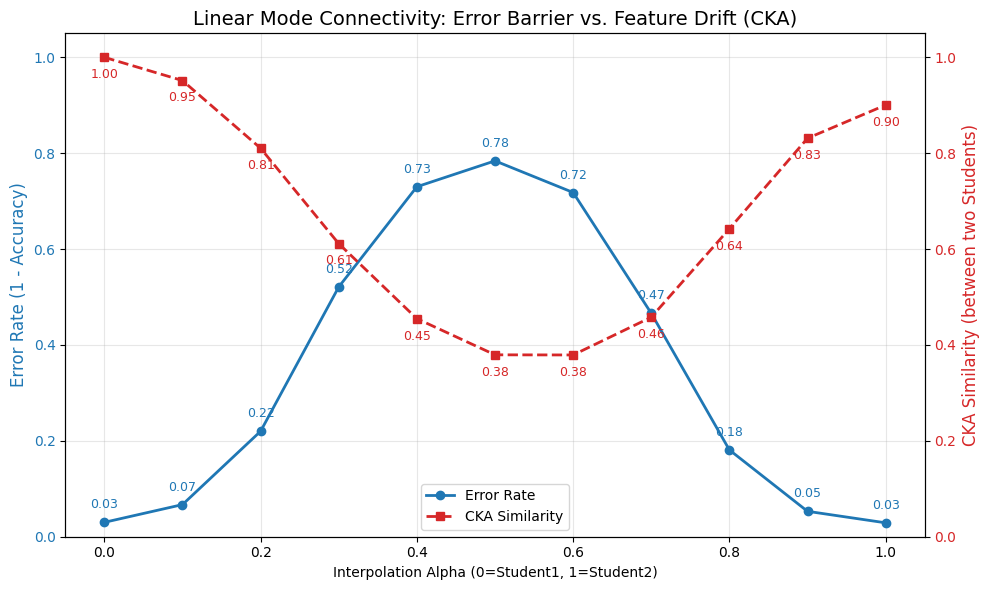

In [6]:
import matplotlib.pyplot as plt

# 1. Extract data (Adjust keys if you used a different structure)
# If using the dictionary format from the last step:
alphas = alphas
errors = errors
ckas = cka_alphas

# 2. Create the figure and the first axis (Error Rate)
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Interpolation Alpha (0=Student1, 1=Student2)')
ax1.set_ylabel('Error Rate (1 - Accuracy)', color=color, fontsize=12)
ax1.plot(alphas, errors, marker='o', linestyle='-', linewidth=2, color=color, label='Error Rate')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.05)

for x, y in zip(alphas, errors):
    ax1.annotate(f'{y:.2f}', 
                 xy=(x, y), 
                 textcoords="offset points", 
                 xytext=(0, 10), # 10pt vertical offset
                 ha='center', 
                 fontsize=9, 
                 color='tab:blue')

# 3. Create the second axis (CKA) sharing the same x-axis
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('CKA Similarity (between two Students)', color=color, fontsize=12)
ax2.plot(alphas, ckas, marker='s', linestyle='--', linewidth=2, color=color, label='CKA Similarity')
ax2.tick_params(axis='y', labelcolor=color)

# Set limits for CKA (Similarity is between 0 and 1)
ax2.set_ylim(0, 1.05) 


# 2. Annotate CKA Similarity (ax2)
for x, y in zip(alphas, ckas):
    ax2.annotate(f'{y:.2f}', 
                 xy=(x, y), 
                 textcoords="offset points", 
                 xytext=(0, -15), # -15pt offset to put text below the marker
                 ha='center', 
                 fontsize=9, 
                 color='tab:red')

# 4. Title and Legend
plt.title("Linear Mode Connectivity: Error Barrier vs. Feature Drift (CKA)", fontsize=14)
fig.tight_layout()

# Add a combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower center')

plt.savefig("lmc_connectivity_between_students_analysis.png")
plt.show()

### Lottery Tickets

In [33]:
pruned_model1 = BigCNN().to(device)

# Apply pruning structure FIRST
parameters_to_prune = get_prunable_layers(pruned_model1)
for m, p in parameters_to_prune:
    prune.identity(m, p)

pruned_model1.load_state_dict(torch.load("models/lth/ticket_model_run0.pth", map_location=device))
final_loss, final_acc = eval_epoch(pruned_model1, test_loader, nn.CrossEntropyLoss(), device=device)
print(f"LTH Pruned model run1 - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

pruned_model1.eval()
    
pruned_model2 = BigCNN().to(device)

# Apply pruning structure FIRST
parameters_to_prune = get_prunable_layers(pruned_model2)
for m, p in parameters_to_prune:
    prune.identity(m, p)

pruned_model2.load_state_dict(torch.load("models/lth/ticket_model_run1.pth", map_location=device))
final_loss, final_acc = eval_epoch(pruned_model2, test_loader, nn.CrossEntropyLoss(), device=device)
print(f"LTH Pruned model run2 - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

pruned_model2.eval()
print()

LTH Pruned model run1 - Acc: 0.9870 | Loss: 0.0524
LTH Pruned model run2 - Acc: 0.9770 | Loss: 0.0796



In [34]:
import copy
def get_interpolated_pruned_model(model1, model2, alpha, device):
    # 1. Create a base model to hold the fused weights
    fused_model = copy.deepcopy(model1).to(device)
    
    # 2. Iterate through named buffers to find the masks
    # PyTorch pruning stores masks in model.named_buffers()
    m1_dict = dict(model1.named_buffers())
    m2_dict = dict(model2.named_buffers())
    m1_weights = dict(model1.named_parameters())
    m2_weights = dict(model2.named_parameters())

    with torch.no_grad():
        for name, param in fused_model.named_parameters():
            if "weight_orig" in name: # Pruned layers use _orig
                mask_name = name.replace("weight_orig", "weight_mask")
                
                # Get masks from both models
                mask1 = m1_dict[mask_name]
                mask2 = m2_dict[mask_name]
                
                # Create Fused Mask (Intersection)
                # Only weights active in BOTH models will remain
                #fused_mask = mask1 * mask2

                # UNION MASK: 1 if either is 1
                fused_mask = torch.max(mask1, mask2)
                
                # Interpolate the underlying weights (_orig)
                w1 = m1_weights[name]
                w2 = m2_weights[name]
                interpolated_weights = (1 - alpha) * w1 + alpha * w2
                
                # Update the fused model
                param.copy_(interpolated_weights)
                dict(fused_model.named_buffers())[mask_name].copy_(fused_mask)
                
            elif "bias" in name:
                # Interpolate biases normally (usually not pruned)
                w1 = m1_weights[name]
                w2 = m2_weights[name]
                param.copy_((1 - alpha) * w1 + alpha * w2)

    return fused_model

In [35]:
#this function interpolates the whole state dict this means that the pruning masks are also interpolated (union) and not just the weights. This is a more "holistic" interpolation that considers the entire pruned structure of both models, rather than just the weights. 
def interpolate_models(model_a, model_b, alpha):
    interp_model = BigCNN().to(next(model_a.parameters()).device)

    # Apply pruning structure FIRST
    parameters_to_prune = get_prunable_layers(interp_model)
    for m, p in parameters_to_prune:
        prune.identity(m, p)

    state_dict = {}
    for (k, v_a), (_, v_b) in zip(
        model_a.state_dict().items(),
        model_b.state_dict().items()
    ):
        state_dict[k] = (1 - alpha) * v_a + alpha * v_b

    interp_model.load_state_dict(state_dict)
    interp_model.eval()
    return interp_model

def recompute_bn_stats(model, data_loader, device, num_batches=50):
    model.train()
    with torch.no_grad():
        for i, (x, _) in enumerate(data_loader):
            if i >= num_batches:
                break
            x = x.to(device)
            model(x)
    model.eval()

In [36]:
losses = []
errors = []
cka_alphas = []

lottery_ticket_layers = {
    "fc": "classifier.1"  # penultimate layer
}

criterion = nn.CrossEntropyLoss()
alphas = np.linspace(0.0, 1.0, 11)
for alpha in alphas:
    interp_model = interpolate_models(pruned_model1, pruned_model2, alpha)
    #interp_model = get_interpolated_pruned_model(pruned_model1, pruned_model2, alpha, device)
    #def count_nonzero(model):
    #    return sum((buf > 0).sum().item() for name, buf in model.named_buffers() if "weight_mask" in name)
    #nz1 = count_nonzero(pruned_model1)
    #nz2 = count_nonzero(pruned_model2)
    #nz_fused = count_nonzero(interp_model)
    #print(f"Non-zeros: Model1: {nz1} | Model2: {nz2} | Fused: {nz_fused}")
    
    cka, _, _ = compute_cka_matrix(
        pruned_model1,
        interp_model,
        lottery_ticket_layers,
        lottery_ticket_layers,
        test_loader,
        device
    )

    cka_val = cka[0][0]
    cka_alphas.append(cka_val)

    recompute_bn_stats(interp_model, train_loader, device)

    loss, acc = eval_epoch(
        interp_model,
        test_loader,
        criterion,
        device=device
    )

    error = 1.0 - acc

    losses.append(loss)
    errors.append(error)

    print(f"α={alpha:.2f} | Accuracy={1-error:.4f} | Error={error:.4f} | CKA={cka_val:.4f}")

endpoint_error = max(errors[0], errors[-1])
max_interp_error = max(errors)

error_barrier = max_interp_error - endpoint_error

print(f"Max interpolation error: {max_interp_error:.4f}")
print(f"Error barrier: {error_barrier:.4f}")


α=0.00 | Accuracy=0.9840 | Error=0.0160 | CKA=1.0000
α=0.10 | Accuracy=0.9840 | Error=0.0160 | CKA=0.9902
α=0.20 | Accuracy=0.9780 | Error=0.0220 | CKA=0.9676
α=0.30 | Accuracy=0.9750 | Error=0.0250 | CKA=0.9394
α=0.40 | Accuracy=0.9540 | Error=0.0460 | CKA=0.9104
α=0.50 | Accuracy=0.9400 | Error=0.0600 | CKA=0.8926
α=0.60 | Accuracy=0.9440 | Error=0.0560 | CKA=0.8952
α=0.70 | Accuracy=0.9560 | Error=0.0440 | CKA=0.9133
α=0.80 | Accuracy=0.9680 | Error=0.0320 | CKA=0.9330
α=0.90 | Accuracy=0.9730 | Error=0.0270 | CKA=0.9449
α=1.00 | Accuracy=0.9730 | Error=0.0270 | CKA=0.9499
Max interpolation error: 0.0600
Error barrier: 0.0330


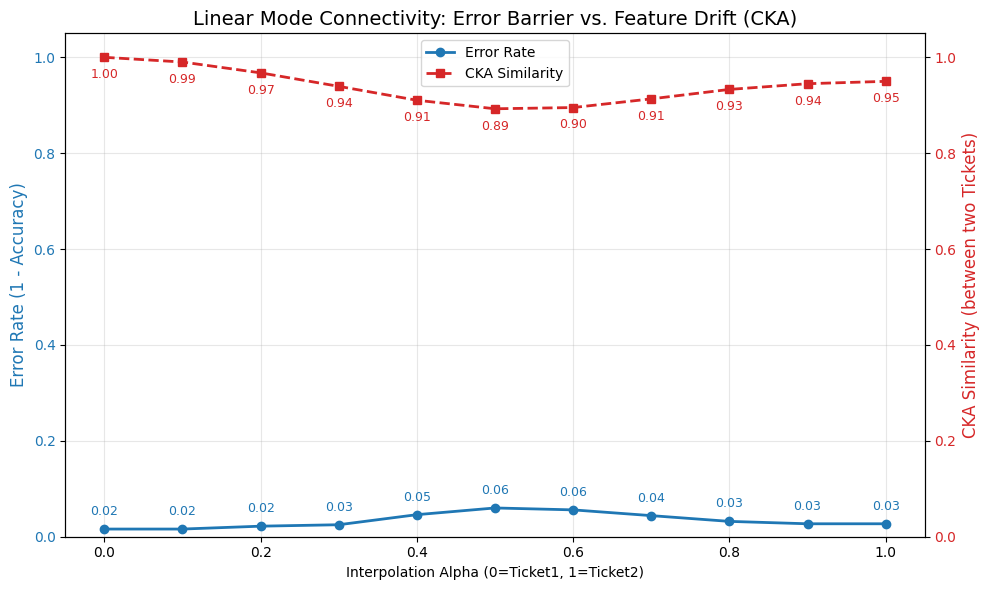

In [37]:
import matplotlib.pyplot as plt

# 1. Extract data (Adjust keys if you used a different structure)
# If using the dictionary format from the last step:
alphas = alphas
errors = errors
ckas = cka_alphas

# 2. Create the figure and the first axis (Error Rate)
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Interpolation Alpha (0=Ticket1, 1=Ticket2)')
ax1.set_ylabel('Error Rate (1 - Accuracy)', color=color, fontsize=12)
ax1.plot(alphas, errors, marker='o', linestyle='-', linewidth=2, color=color, label='Error Rate')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.05)   # Adjust the Error Rate scale

# 1. Annotate Error Rate (ax1)
for x, y in zip(alphas, errors):
    ax1.annotate(f'{y:.2f}', 
                 xy=(x, y), 
                 textcoords="offset points", 
                 xytext=(0, 10), # 10pt vertical offset
                 ha='center', 
                 fontsize=9, 
                 color='tab:blue')

# 3. Create the second axis (CKA) sharing the same x-axis
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('CKA Similarity (between two Tickets)', color=color, fontsize=12)
ax2.plot(alphas, ckas, marker='s', linestyle='--', linewidth=2, color=color, label='CKA Similarity')
ax2.tick_params(axis='y', labelcolor=color)

# Set limits for CKA (Similarity is between 0 and 1)
ax2.set_ylim(0, 1.05) 
# 2. Annotate CKA Similarity (ax2)
for x, y in zip(alphas, ckas):
    ax2.annotate(f'{y:.2f}', 
                 xy=(x, y), 
                 textcoords="offset points", 
                 xytext=(0, -15), # -15pt offset to put text below the marker
                 ha='center', 
                 fontsize=9, 
                 color='tab:red')

# 4. Title and Legend
plt.title("Linear Mode Connectivity: Error Barrier vs. Feature Drift (CKA)", fontsize=14)
fig.tight_layout()

# Add a combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center')

plt.savefig("lmc_connectivity_between_tickets_analysis.png")
plt.show()

#### Retraining the classifier of the interpolated model

In [38]:
from torch.optim.lr_scheduler import CosineAnnealingLR
from lth_utils import train_model
import wandb
import torch
import torch.nn as nn
import numpy as np

# Define the range of alpha values (e.g., 0.0, 0.1, ..., 1.0)
alphas = np.linspace(0, 1, 11)
retrained_head_errors = []
for alpha in alphas:
    # 1. Interpolate and prepare model
    interp_model = interpolate_models(pruned_model1, pruned_model2, alpha)
    interp_model.to(device)
    
    # Freeze all parameters first
    for param in interp_model.parameters():
        param.requires_grad = False

    # 2. Identify the head (classifier[4]) and unfreeze
    head = interp_model.classifier[4]
    trainable_params = []

    # Handle weight_orig (for models using weight_norm) or standard weight
    if hasattr(head, "weight_orig"):
        head.weight_orig.requires_grad = True
        trainable_params.append(head.weight_orig)
    else:
        head.weight.requires_grad = True
        trainable_params.append(head.weight)

    if head.bias is not None:
        head.bias.requires_grad = True
        trainable_params.append(head.bias)

    # 3. Re-initialize the head
    with torch.no_grad():
        if hasattr(head, "weight_orig"):
            nn.init.kaiming_normal_(head.weight_orig)
        else:
            nn.init.kaiming_normal_(head.weight)

        if head.bias is not None:
            nn.init.zeros_(head.bias)

    # 4. Setup Training
    head_epochs = 100
    optimizer = torch.optim.Adam(trainable_params, lr=1e-3)
    scheduler = CosineAnnealingLR(optimizer, T_max=head_epochs)

    # 5. Logging and Training
    wandb.init(
        project="mnist-1d-KDvsLTH",
        name=f"LTH-Interp-Head-Retrain-Alpha{alpha:.2f}",
        group="Linear-mode-connectivity",
        config={
            "learning_rate": 0.001,
            "epochs": head_epochs,
            "architecture": "BigCNN-Interp-Head-Retrain",
            "alpha": alpha
        }
    )

    history = train_model(
        interp_model,
        device,
        train_loader,
        test_loader,
        optimizer,
        scheduler,
        epochs=head_epochs,
        round_idx=f"head_retrain_alpha_{alpha:.2f}"
    )

    loss, acc = eval_epoch(
        interp_model,
        test_loader,
        criterion,
        device=device
    )

    error = 1.0 - acc
    retrained_head_errors.append(error)
    
    wandb.log({
        "alpha": alpha,
        "error": error,
        "loss": loss
    })
    wandb.finish()

Round head_retrain_alpha_0.00 | Epoch 1 | Val Acc: 52.00%
Round head_retrain_alpha_0.00 | Epoch 2 | Val Acc: 65.20%
Round head_retrain_alpha_0.00 | Epoch 3 | Val Acc: 66.00%
Round head_retrain_alpha_0.00 | Epoch 4 | Val Acc: 66.50%
Round head_retrain_alpha_0.00 | Epoch 5 | Val Acc: 75.00%
Round head_retrain_alpha_0.00 | Epoch 6 | Val Acc: 83.40%
Round head_retrain_alpha_0.00 | Epoch 7 | Val Acc: 91.50%
Round head_retrain_alpha_0.00 | Epoch 8 | Val Acc: 95.40%
Round head_retrain_alpha_0.00 | Epoch 9 | Val Acc: 95.70%
Round head_retrain_alpha_0.00 | Epoch 10 | Val Acc: 95.70%
Round head_retrain_alpha_0.00 | Epoch 11 | Val Acc: 95.80%
Round head_retrain_alpha_0.00 | Epoch 12 | Val Acc: 96.70%
Round head_retrain_alpha_0.00 | Epoch 13 | Val Acc: 96.80%
Round head_retrain_alpha_0.00 | Epoch 14 | Val Acc: 97.10%
Round head_retrain_alpha_0.00 | Epoch 15 | Val Acc: 97.00%
Round head_retrain_alpha_0.00 | Epoch 16 | Val Acc: 97.40%
Round head_retrain_alpha_0.00 | Epoch 17 | Val Acc: 97.30%
Round 

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


alpha,▁
error,▁
loss,▁
round_head_retrain_alpha_0.00/train_loss,█▅▄▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
round_head_retrain_alpha_0.00/val_acc,▁▃▃▆████████████████████████████████████
alpha,0
error,0.015
loss,0.06337
round_head_retrain_alpha_0.00/train_loss,0.10068
round_head_retrain_alpha_0.00/val_acc,98.5


Round head_retrain_alpha_0.10 | Epoch 1 | Val Acc: 23.70%
Round head_retrain_alpha_0.10 | Epoch 2 | Val Acc: 38.30%
Round head_retrain_alpha_0.10 | Epoch 3 | Val Acc: 41.20%
Round head_retrain_alpha_0.10 | Epoch 4 | Val Acc: 42.70%
Round head_retrain_alpha_0.10 | Epoch 5 | Val Acc: 55.20%
Round head_retrain_alpha_0.10 | Epoch 6 | Val Acc: 85.90%
Round head_retrain_alpha_0.10 | Epoch 7 | Val Acc: 96.40%
Round head_retrain_alpha_0.10 | Epoch 8 | Val Acc: 97.80%
Round head_retrain_alpha_0.10 | Epoch 9 | Val Acc: 97.80%
Round head_retrain_alpha_0.10 | Epoch 10 | Val Acc: 97.80%
Round head_retrain_alpha_0.10 | Epoch 11 | Val Acc: 98.00%
Round head_retrain_alpha_0.10 | Epoch 12 | Val Acc: 97.90%
Round head_retrain_alpha_0.10 | Epoch 13 | Val Acc: 98.00%
Round head_retrain_alpha_0.10 | Epoch 14 | Val Acc: 97.90%
Round head_retrain_alpha_0.10 | Epoch 15 | Val Acc: 97.90%
Round head_retrain_alpha_0.10 | Epoch 16 | Val Acc: 97.90%
Round head_retrain_alpha_0.10 | Epoch 17 | Val Acc: 97.90%
Round 

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


...

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


alpha,▁
error,▁
loss,▁
round_head_retrain_alpha_0.90/train_loss,█▇▇▆▅▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
round_head_retrain_alpha_0.90/val_acc,▁▁▂█████████████████████████████████████
alpha,0.9
error,0.026
loss,0.09311
round_head_retrain_alpha_0.90/train_loss,0.13265
round_head_retrain_alpha_0.90/val_acc,97.4


Round head_retrain_alpha_1.00 | Epoch 1 | Val Acc: 20.50%
Round head_retrain_alpha_1.00 | Epoch 2 | Val Acc: 26.50%
Round head_retrain_alpha_1.00 | Epoch 3 | Val Acc: 30.30%
Round head_retrain_alpha_1.00 | Epoch 4 | Val Acc: 32.20%
Round head_retrain_alpha_1.00 | Epoch 5 | Val Acc: 47.90%
Round head_retrain_alpha_1.00 | Epoch 6 | Val Acc: 77.70%
Round head_retrain_alpha_1.00 | Epoch 7 | Val Acc: 91.70%
Round head_retrain_alpha_1.00 | Epoch 8 | Val Acc: 93.70%
Round head_retrain_alpha_1.00 | Epoch 9 | Val Acc: 94.50%
Round head_retrain_alpha_1.00 | Epoch 10 | Val Acc: 94.30%
Round head_retrain_alpha_1.00 | Epoch 11 | Val Acc: 95.00%
Round head_retrain_alpha_1.00 | Epoch 12 | Val Acc: 95.10%
Round head_retrain_alpha_1.00 | Epoch 13 | Val Acc: 95.00%
Round head_retrain_alpha_1.00 | Epoch 14 | Val Acc: 95.80%
Round head_retrain_alpha_1.00 | Epoch 15 | Val Acc: 95.70%
Round head_retrain_alpha_1.00 | Epoch 16 | Val Acc: 95.20%
Round head_retrain_alpha_1.00 | Epoch 17 | Val Acc: 95.30%
Round 

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


alpha,▁
error,▁
loss,▁
round_head_retrain_alpha_1.00/train_loss,█▇▇▆▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
round_head_retrain_alpha_1.00/val_acc,▁███████████████████████████████████████
alpha,1
error,0.027
loss,0.09326
round_head_retrain_alpha_1.00/train_loss,0.10534
round_head_retrain_alpha_1.00/val_acc,97.3


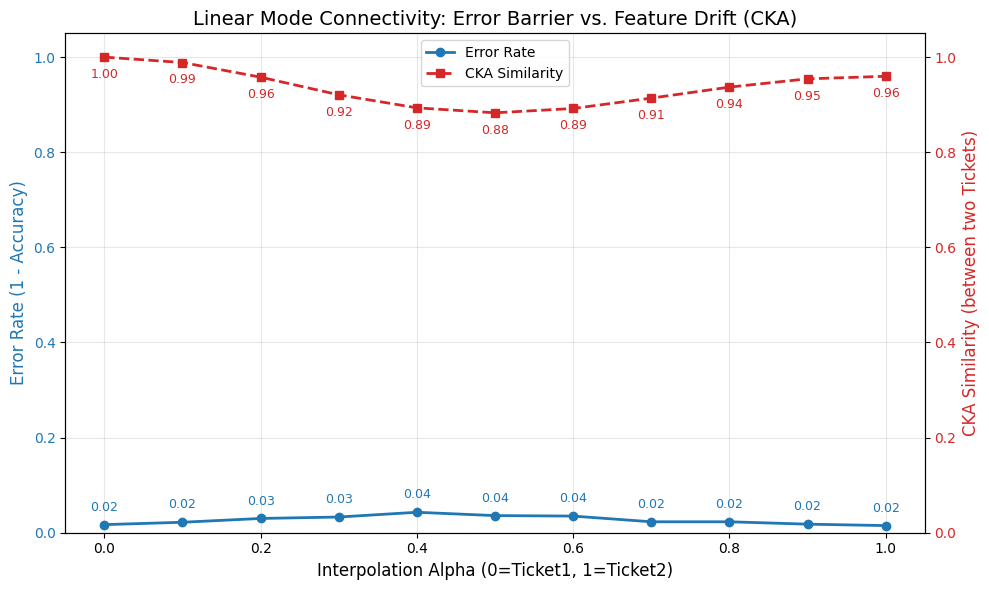

In [13]:
import matplotlib.pyplot as plt

# 1. Extract data (Adjust keys if you used a different structure)
# If using the dictionary format from the last step:
alphas = alphas
retrained_head_errors = retrained_head_errors
ckas = cka_alphas

# 2. Create the figure and the first axis (Error Rate)
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Interpolation Alpha (0=Ticket1, 1=Ticket2)', fontsize=12)
ax1.set_ylabel('Error Rate (1 - Accuracy)', color=color, fontsize=12)
ax1.plot(alphas, retrained_head_errors, marker='o', linestyle='-', linewidth=2, color=color, label='Error Rate')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.05)

# 3. Create the second axis (CKA) sharing the same x-axis
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('CKA Similarity (between two Tickets)', color=color, fontsize=12)
ax2.plot(alphas, ckas, marker='s', linestyle='--', linewidth=2, color=color, label='CKA Similarity')
ax2.tick_params(axis='y', labelcolor=color)
# 1. Annotate Error Rate (ax1)
for x, y in zip(alphas, retrained_head_errors):
    ax1.annotate(f'{y:.2f}', 
                 xy=(x, y), 
                 textcoords="offset points", 
                 xytext=(0, 10), # 10pt vertical offset
                 ha='center', 
                 fontsize=9, 
                 color='tab:blue')

# Set limits for CKA (Similarity is between 0 and 1)
ax2.set_ylim(0, 1.05)
# 2. Annotate CKA Similarity (ax2)
for x, y in zip(alphas, ckas):
    ax2.annotate(f'{y:.2f}', 
                 xy=(x, y), 
                 textcoords="offset points", 
                 xytext=(0, -15), # -15pt offset to put text below the marker
                 ha='center', 
                 fontsize=9, 
                 color='tab:red')

# 4. Title and Legend
plt.title("Linear Mode Connectivity: Error Barrier vs. Feature Drift (CKA)", fontsize=14)
fig.tight_layout()

# Add a combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center')

plt.savefig("lmc_connectivity_between_tickets_head_retrained_analysis.png")
plt.show()

### Matching models Linear connectivity

In [14]:
matching_model1 = BigCNN().to(device)

# Apply pruning structure FIRST
parameters_to_prune = get_prunable_layers(matching_model1)
for m, p in parameters_to_prune:
    prune.identity(m, p)

matching_model1.load_state_dict(torch.load("models/matching/matching_model_run0.pth", map_location=device))
final_loss, final_acc = eval_epoch(matching_model1, test_loader, nn.CrossEntropyLoss(), device=device)
print(f"matching model run1 - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

matching_model1.eval()
    
matching_model2 = BigCNN().to(device)

# Apply pruning structure FIRST
parameters_to_prune = get_prunable_layers(matching_model2)
for m, p in parameters_to_prune:
    prune.identity(m, p)

matching_model2.load_state_dict(torch.load("models/matching/matching_model_run1.pth", map_location=device))
final_loss, final_acc = eval_epoch(matching_model2, test_loader, nn.CrossEntropyLoss(), device=device)
print(f"matching model run2 - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

matching_model2.eval()
print()

matching model run1 - Acc: 0.9850 | Loss: 0.0610
matching model run2 - Acc: 0.9840 | Loss: 0.0573



In [15]:
import numpy as np
losses = []
errors = []
cka_alphas = []

lottery_ticket_layers = {
    "fc": "classifier.1"  # penultimate layer
}

criterion = nn.CrossEntropyLoss()
alphas = np.linspace(0.0, 1.0, 11)
for alpha in alphas:
    interp_model = interpolate_models(matching_model1, matching_model2, alpha)
    
    cka, _, _ = compute_cka_matrix(
        matching_model1,
        interp_model,
        lottery_ticket_layers,
        lottery_ticket_layers,
        test_loader,
        device
    )

    cka_val = cka[0][0]
    cka_alphas.append(cka_val)

    recompute_bn_stats(interp_model, train_loader, device)

    loss, acc = eval_epoch(
        interp_model,
        test_loader,
        criterion,
        device=device
    )

    error = 1.0 - acc

    losses.append(loss)
    errors.append(error)

    print(f"α={alpha:.2f} | Error={error:.4f} | CKA={cka_val:.4f}")

endpoint_error = max(errors[0], errors[-1])
max_interp_error = max(errors)

error_barrier = max_interp_error - endpoint_error

print(f"Max interpolation error: {max_interp_error:.4f}")
print(f"Error barrier: {error_barrier:.4f}")


α=0.00 | Error=0.0200 | CKA=1.0000
α=0.10 | Error=0.0200 | CKA=0.9988
α=0.20 | Error=0.0200 | CKA=0.9961
α=0.30 | Error=0.0200 | CKA=0.9930
α=0.40 | Error=0.0220 | CKA=0.9900
α=0.50 | Error=0.0220 | CKA=0.9874
α=0.60 | Error=0.0240 | CKA=0.9852
α=0.70 | Error=0.0200 | CKA=0.9833
α=0.80 | Error=0.0190 | CKA=0.9815
α=0.90 | Error=0.0180 | CKA=0.9793
α=1.00 | Error=0.0160 | CKA=0.9763
Max interpolation error: 0.0240
Error barrier: 0.0040


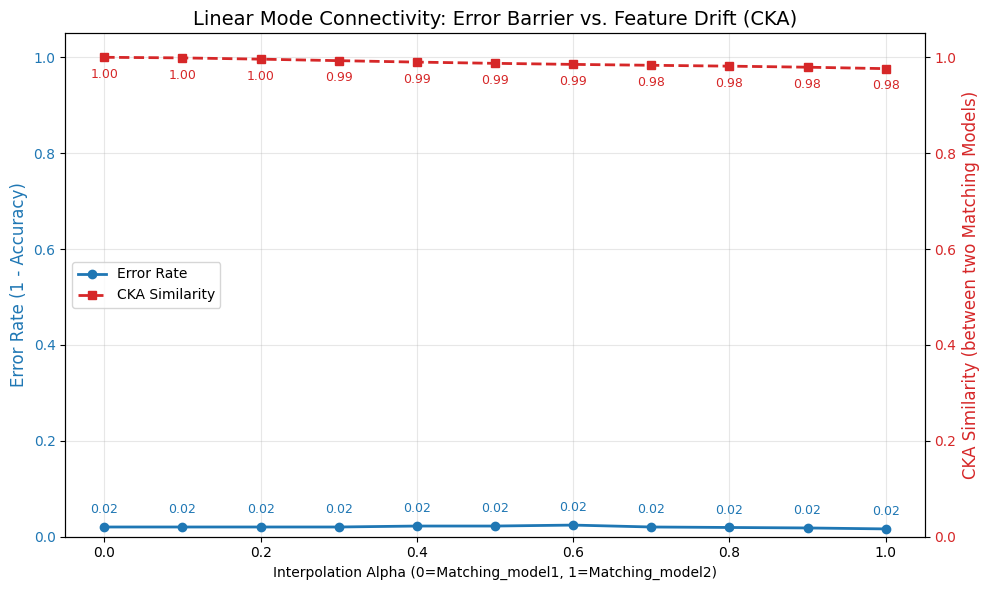

In [16]:
import matplotlib.pyplot as plt

# 1. Extract data (Adjust keys if you used a different structure)
# If using the dictionary format from the last step:
alphas = alphas
errors = errors
ckas = cka_alphas

# 2. Create the figure and the first axis (Error Rate)
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Interpolation Alpha (0=Matching_model1, 1=Matching_model2)')
ax1.set_ylabel('Error Rate (1 - Accuracy)', color=color, fontsize=12)
ax1.plot(alphas, errors, marker='o', linestyle='-', linewidth=2, color=color, label='Error Rate')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.05)

for x, y in zip(alphas, errors):
    ax1.annotate(f'{y:.2f}', 
                 xy=(x, y), 
                 textcoords="offset points", 
                 xytext=(0, 10), # 10pt vertical offset
                 ha='center', 
                 fontsize=9, 
                 color='tab:blue')

# 3. Create the second axis (CKA) sharing the same x-axis
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('CKA Similarity (between two Matching Models)', color=color, fontsize=12)
ax2.plot(alphas, ckas, marker='s', linestyle='--', linewidth=2, color=color, label='CKA Similarity')
ax2.tick_params(axis='y', labelcolor=color)

# Set limits for CKA (Similarity is between 0 and 1)
ax2.set_ylim(0, 1.05) 


# 2. Annotate CKA Similarity (ax2)
for x, y in zip(alphas, ckas):
    ax2.annotate(f'{y:.2f}', 
                 xy=(x, y), 
                 textcoords="offset points", 
                 xytext=(0, -15), # -15pt offset to put text below the marker
                 ha='center', 
                 fontsize=9, 
                 color='tab:red')

# 4. Title and Legend
plt.title("Linear Mode Connectivity: Error Barrier vs. Feature Drift (CKA)", fontsize=14)
fig.tight_layout()

# Add a combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')

plt.savefig("lmc_connectivity_between_matching_models_analysis.png")
plt.show()